In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from matching_pairs_list import matching_pairs

## Adaptive Dual-Threshold Edge Detection for Watermark Detection

**Automatically calculates optimal thresholds for each image**

This method:
1. Scans Canny at multiple thresholds (10-255)
2. Finds the "effective max" where edges stop appearing
3. Calculates `mid` and `high` thresholds as ratios of effective max
4. Applies dual-threshold detection with custom thresholds

**How Dual-Threshold Works:**
- Strong edges (high threshold) = main image content
- All edges (mid threshold) = content + watermarks
- Watermark edges = All - Strong (isolates watermarks)

In [14]:
def calculate_adaptive_thresholds(image_path):
    """
    Calculate adaptive thresholds using CANNY edge detection with max_ratio method.
    Returns TWO thresholds: mid (minimum edge strength) and high (strong edges).
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    blurred = cv2.GaussianBlur(img, (5, 5), 1.5)
    
    test_range = range(10, 255, 5)
    max_edges_found = 0
    effective_max = 255
    
    for thresh in test_range:
        edges = cv2.Canny(blurred, thresh, thresh * 2)
        edge_count = np.count_nonzero(edges)
        
        if edge_count > max_edges_found:
            max_edges_found = edge_count
        
        if edge_count < max_edges_found * 0.01:
            effective_max = thresh
            break
    
    MID_RATIO = 0.33
    HIGH_RATIO = 0.66
    
    mid_thresh = max(20, effective_max * MID_RATIO)
    high_thresh = max(mid_thresh + 30, effective_max * HIGH_RATIO)
    
    return int(mid_thresh), int(high_thresh)


def dual_threshold_watermark_detection(image_path, mid_thresh=60, high_thresh=150):
    """
    Detect watermarks using dual threshold approach.
    Strong edges (high threshold) = main image content
    Medium edges (between mid and high) = likely watermarks
    """
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)
    
    strong_edges = cv2.Canny(blurred, high_thresh, high_thresh * 2)
    all_edges = cv2.Canny(blurred, mid_thresh, high_thresh)
    watermark_edges = cv2.bitwise_and(all_edges, cv2.bitwise_not(strong_edges))
    
    kernel = np.ones((2, 2), np.uint8)
    watermark_edges_cleaned = cv2.morphologyEx(watermark_edges, cv2.MORPH_CLOSE, kernel)
    
    return img_rgb, strong_edges, all_edges, watermark_edges_cleaned

## Evaluation on Matching Pairs Dataset

**Ground Truth Generation:**
- Apply Canny edge detection to both watermarked and clean images
- Subtract clean edges from watermarked edges to get "watermark-only" edges

**Metrics Calculated:**
- **Accuracy**: (TP + TN) / Total
- **Precision**: TP / (TP + FP)
- **Recall**: TP / (TP + FN)
- **F1 Score**: Harmonic mean of Precision and Recall
- **Specificity**: TN / (TN + FP)

In [15]:
def generate_ground_truth_mask(watermark_path, clean_path, threshold=50):
    """Generate ground truth watermark mask by comparing watermarked and clean images."""
    wm_img = cv2.imread(watermark_path, cv2.IMREAD_GRAYSCALE)
    clean_img = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    
    if wm_img is None or clean_img is None:
        return None
    
    if wm_img.shape != clean_img.shape:
        clean_img = cv2.resize(clean_img, (wm_img.shape[1], wm_img.shape[0]))
    
    wm_blurred = cv2.GaussianBlur(wm_img, (5, 5), 1.5)
    clean_blurred = cv2.GaussianBlur(clean_img, (5, 5), 1.5)
    
    wm_edges = cv2.Canny(wm_blurred, threshold, threshold * 2)
    clean_edges = cv2.Canny(clean_blurred, threshold, threshold * 2)
    
    ground_truth = cv2.bitwise_and(wm_edges, cv2.bitwise_not(clean_edges))
    
    kernel = np.ones((2, 2), np.uint8)
    ground_truth = cv2.morphologyEx(ground_truth, cv2.MORPH_CLOSE, kernel)
    
    return ground_truth


def calculate_metrics(prediction, ground_truth):
    """Calculate classification metrics for watermark detection."""
    pred = (prediction > 0).astype(np.uint8).flatten()
    gt = (ground_truth > 0).astype(np.uint8).flatten()
    
    TP = np.sum((pred == 1) & (gt == 1))
    TN = np.sum((pred == 0) & (gt == 0))
    FP = np.sum((pred == 1) & (gt == 0))
    FN = np.sum((pred == 0) & (gt == 1))
    
    total = TP + TN + FP + FN
    
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'accuracy': accuracy, 'precision': precision, 'recall': recall,
        'f1': f1, 'specificity': specificity,
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
    }

In [16]:
# Evaluate adaptive dual-threshold
all_metrics = []
failed_pairs = 0

for pair in tqdm(matching_pairs, desc="Processing pairs"):
    watermark_path = pair['watermark']
    clean_path = pair['no_watermark']
    
    if not os.path.exists(watermark_path) or not os.path.exists(clean_path):
        failed_pairs += 1
        continue
    
    ground_truth = generate_ground_truth_mask(watermark_path, clean_path)
    if ground_truth is None:
        failed_pairs += 1
        continue
    
    mid, high = calculate_adaptive_thresholds(watermark_path)
    _, _, _, predicted_mask = dual_threshold_watermark_detection(watermark_path, mid, high)
    
    if predicted_mask.shape != ground_truth.shape:
        predicted_mask = cv2.resize(predicted_mask, (ground_truth.shape[1], ground_truth.shape[0]))
    
    metrics = calculate_metrics(predicted_mask, ground_truth)
    all_metrics.append(metrics)

Processing pairs: 100%|██████████| 1850/1850 [00:20<00:00, 89.42it/s] 


In [20]:
# Calculate metrics over all pixels from all images
total_TP = sum(m['TP'] for m in all_metrics)
total_TN = sum(m['TN'] for m in all_metrics)
total_FP = sum(m['FP'] for m in all_metrics)
total_FN = sum(m['FN'] for m in all_metrics)

total_pixels = total_TP + total_TN + total_FP + total_FN
accuracy = (total_TP + total_TN) / total_pixels
precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
specificity = total_TN / (total_TN + total_FP) if (total_TN + total_FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("ADAPTIVE DUAL-THRESHOLD WATERMARK DETECTION RESULTS")
print(f"\nDataset: {len(all_metrics)} image pairs")
print(f"Total pixels evaluated: {total_pixels:,}")
print(f"\n{'METRIC':<20} {'VALUE':>12}")
print(f"{'Accuracy':<20} {accuracy:>12.4f}")
print(f"{'Precision':<20} {precision:>12.4f}")
print(f"{'Recall':<20} {recall:>12.4f}")
print(f"{'F1 Score':<20} {f1:>12.4f}")
print(f"{'Specificity':<20} {specificity:>12.4f}")

ADAPTIVE DUAL-THRESHOLD WATERMARK DETECTION RESULTS

Dataset: 1850 image pairs
Total pixels evaluated: 267,036,350

METRIC                      VALUE
Accuracy                   0.9596
Precision                  0.1373
Recall                     0.4491
F1 Score                   0.2103
Specificity                0.9658


Visualizing sample predictions vs ground truth...



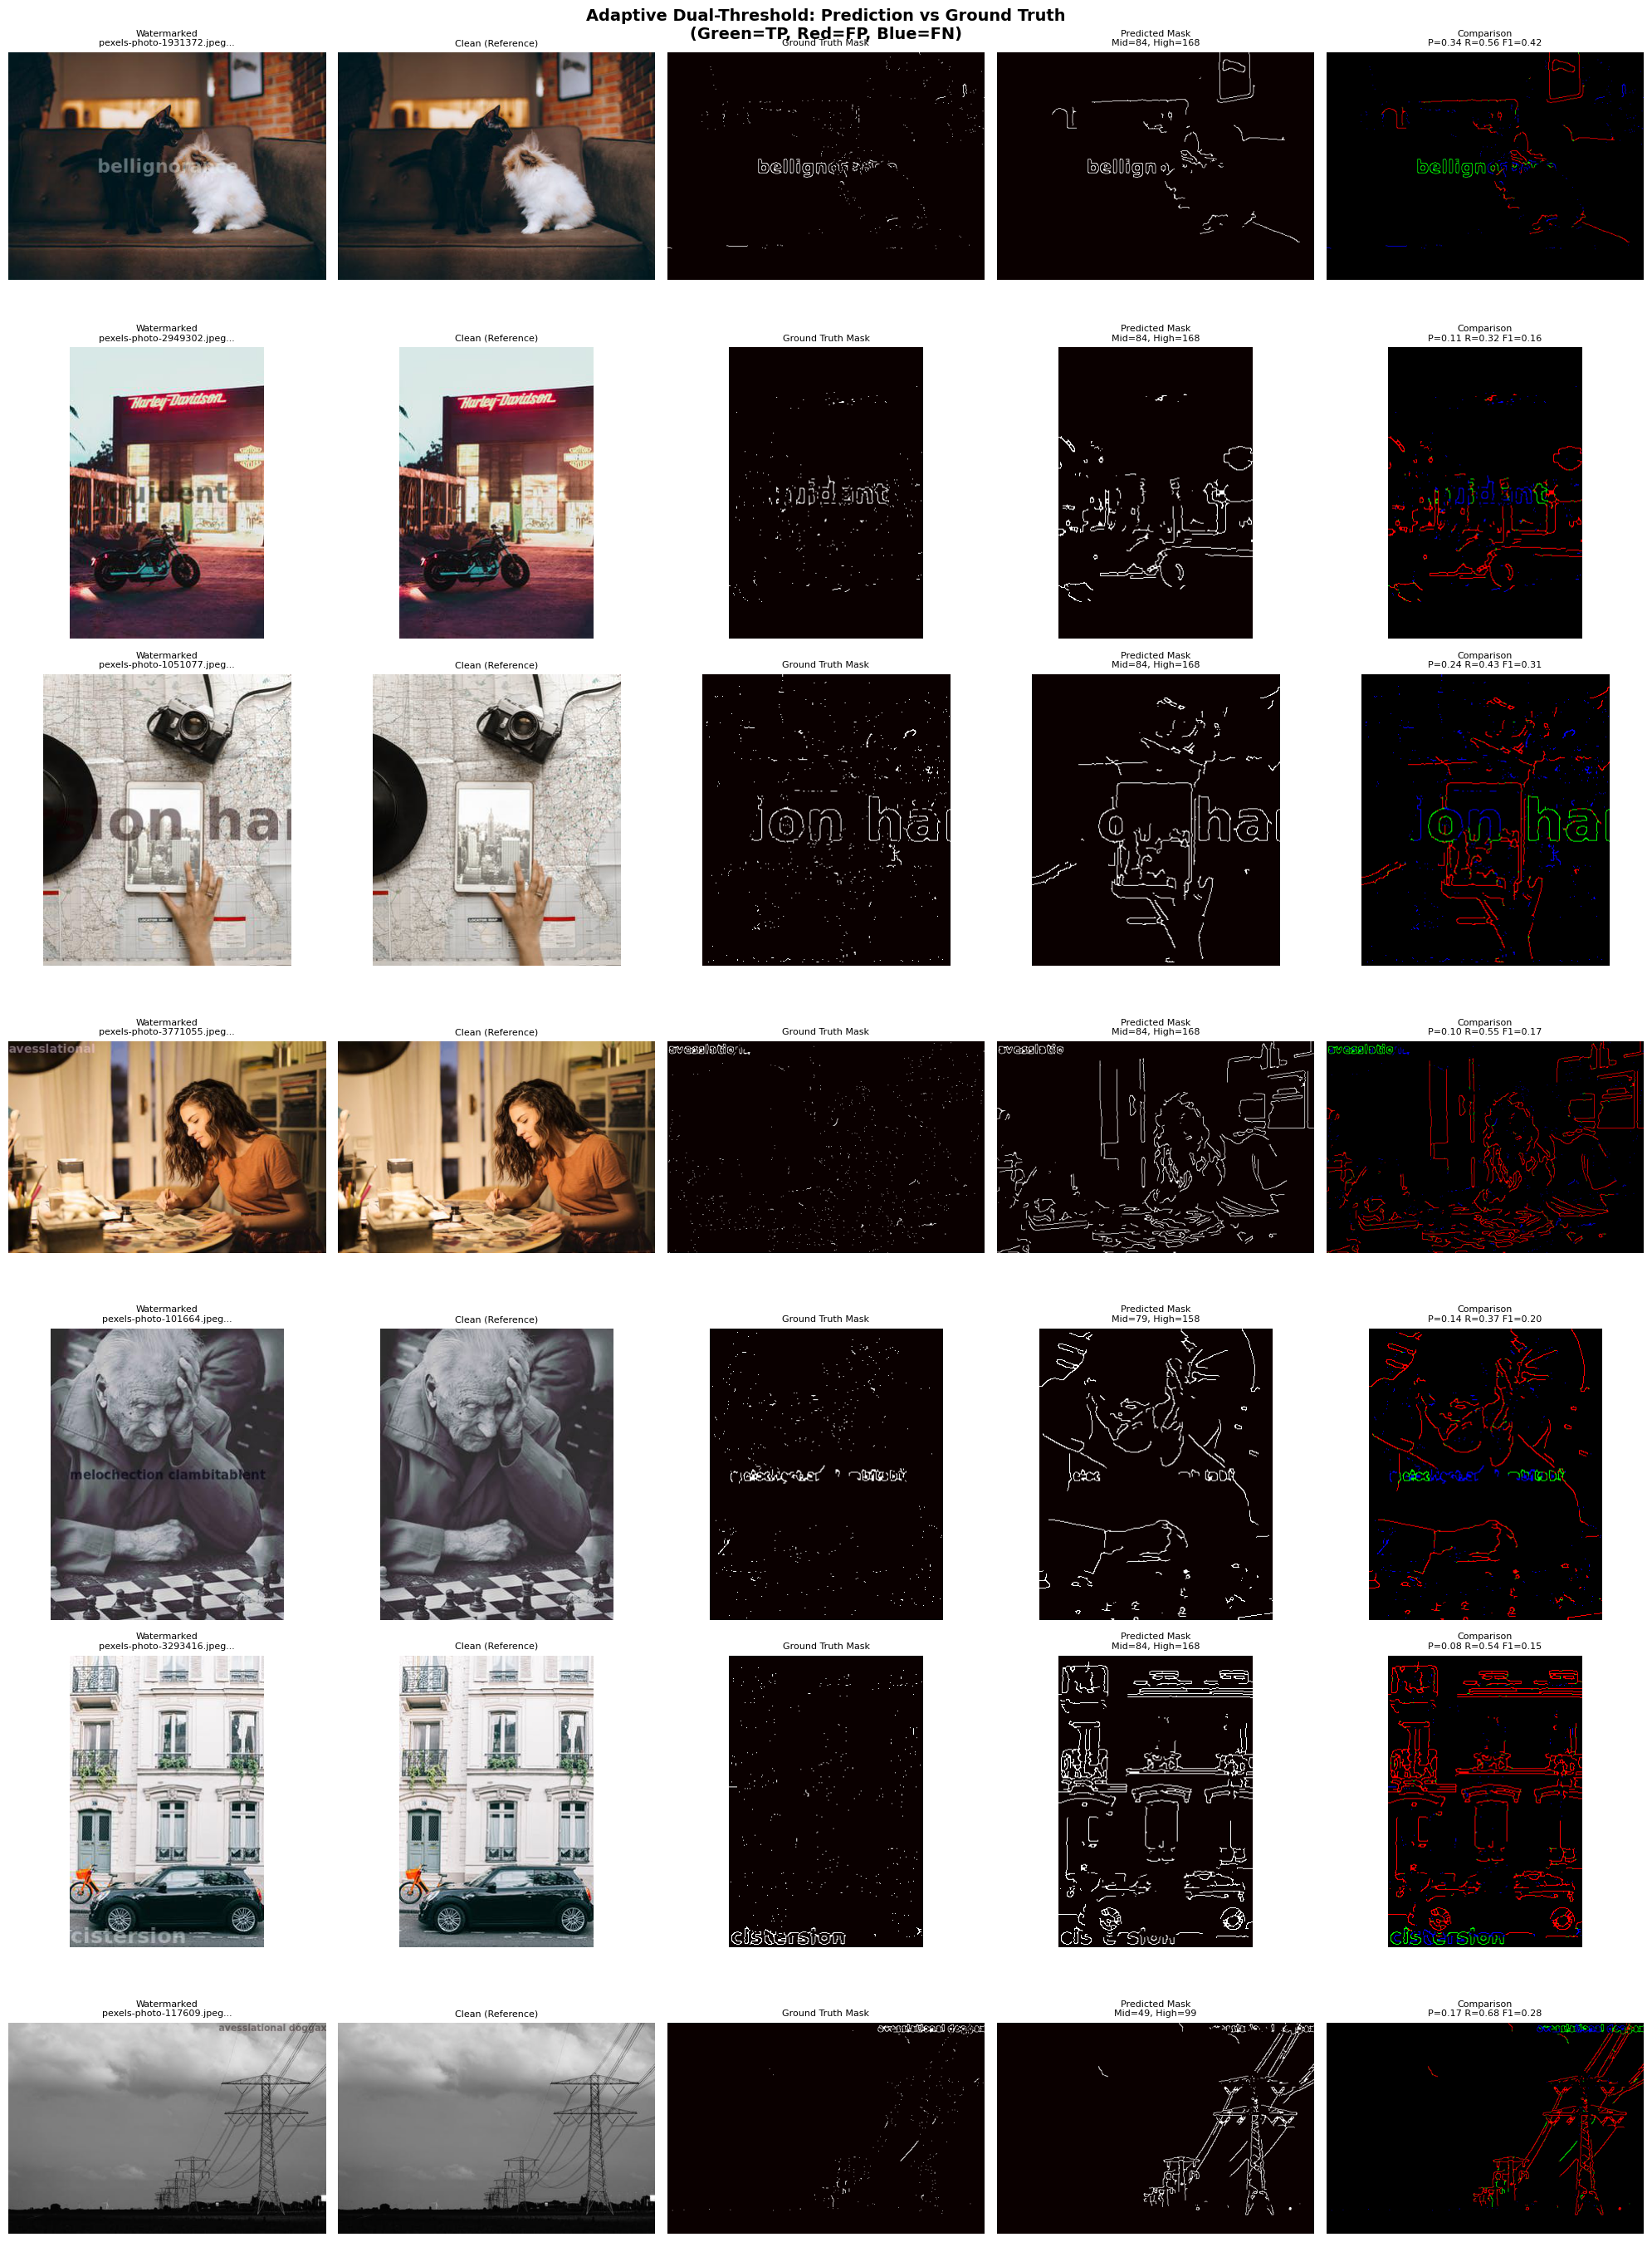


Legend: 🟢 Green=TP  🔴 Red=FP  🔵 Blue=FN


In [18]:
# Visualize examples: Prediction vs Ground Truth
print("Visualizing sample predictions vs ground truth...\n")

np.random.seed(42)
sample_indices = np.random.choice(len(matching_pairs), size=7, replace=False)

fig, axes = plt.subplots(7, 5, figsize=(20, 28))

for idx, sample_idx in enumerate(sample_indices):
    pair = matching_pairs[sample_idx]
    watermark_path = pair['watermark']
    clean_path = pair['no_watermark']
    
    img_rgb = cv2.cvtColor(cv2.imread(watermark_path), cv2.COLOR_BGR2RGB)
    clean_rgb = cv2.cvtColor(cv2.imread(clean_path), cv2.COLOR_BGR2RGB)
    
    ground_truth = generate_ground_truth_mask(watermark_path, clean_path)
    mid, high = calculate_adaptive_thresholds(watermark_path)
    _, _, _, predicted_mask = dual_threshold_watermark_detection(watermark_path, mid, high)
    
    if predicted_mask.shape != ground_truth.shape:
        predicted_mask = cv2.resize(predicted_mask, (ground_truth.shape[1], ground_truth.shape[0]))
    
    metrics = calculate_metrics(predicted_mask, ground_truth)
    
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f"Watermarked\n{pair['filename'][:25]}...", fontsize=8)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(clean_rgb)
    axes[idx, 1].set_title("Clean (Reference)", fontsize=8)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(ground_truth, cmap='hot')
    axes[idx, 2].set_title("Ground Truth Mask", fontsize=8)
    axes[idx, 2].axis('off')
    
    axes[idx, 3].imshow(predicted_mask, cmap='hot')
    axes[idx, 3].set_title(f"Predicted Mask\nMid={mid}, High={high}", fontsize=8)
    axes[idx, 3].axis('off')
    
    pred_binary = (predicted_mask > 0).astype(np.uint8)
    gt_binary = (ground_truth > 0).astype(np.uint8)
    comparison = np.zeros((*pred_binary.shape, 3), dtype=np.uint8)
    comparison[..., 1] = ((pred_binary == 1) & (gt_binary == 1)).astype(np.uint8) * 255
    comparison[..., 0] = ((pred_binary == 1) & (gt_binary == 0)).astype(np.uint8) * 255
    comparison[..., 2] = ((pred_binary == 0) & (gt_binary == 1)).astype(np.uint8) * 255
    
    axes[idx, 4].imshow(comparison)
    axes[idx, 4].set_title(f"Comparison\nP={metrics['precision']:.2f} R={metrics['recall']:.2f} F1={metrics['f1']:.2f}", fontsize=8)
    axes[idx, 4].axis('off')

plt.suptitle('Adaptive Dual-Threshold: Prediction vs Ground Truth\n(Green=TP, Red=FP, Blue=FN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLegend: 🟢 Green=TP  🔴 Red=FP  🔵 Blue=FN")